In [1]:
import uuid
from dataclasses import dataclass
from langgraph.runtime import Runtime
from langchain_ollama import ChatOllama
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import MessagesState, StateGraph, START, END

@dataclass
class Context:
    user_id: str

checkpointer = InMemorySaver()
store = InMemoryStore()
llm = ChatOllama(model="qwen2.5")

In [2]:
async def save_memory(state: MessagesState, runtime: Runtime[Context]):
    user_id = runtime.context.user_id
    namespace = (user_id, "memories")
    last_message = state["messages"][-1].content
    
    memory = f"User said: {last_message}"
    memory_id = str(uuid.uuid4())
    await runtime.store.aput(namespace, memory_id, {"memory": memory})
    return state

In [3]:
async def call_model(state: MessagesState, runtime: Runtime[Context]):
    user_id = runtime.context.user_id
    namespace = (user_id, "memories")
    memories = await runtime.store.asearch(
        namespace,
        query=state["messages"][-1].content,
        limit=3
    )

    # Convert memory to text
    info = "\n".join([m.value["memory"] for m in memories])

    # Add memory into prompt
    system_msg = {
        "role": "system",
        "content": f"User info:\n{info}"
    }

    messages = [system_msg] + state["messages"]
    response = await llm.ainvoke(messages)
    return {"messages": [response]}

In [4]:
builder = StateGraph(MessagesState, context_schema=Context)

builder.add_node("save_memory", save_memory)
builder.add_node("call_model", call_model)

builder.add_edge(START, "save_memory")
builder.add_edge("save_memory", "call_model")
builder.add_edge("call_model", END)

graph = builder.compile(checkpointer=checkpointer, store=store)

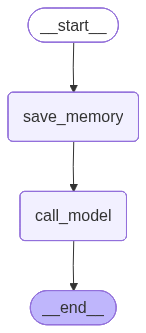

In [5]:
graph

In [5]:
config = {"configurable": {"thread_id": "1"}}

print("\n--- First Conversation ---\n")

async for update in graph.astream(
    {"messages": [{"role": "user", "content": "I like pizza"}]},
    config,
    stream_mode="updates",
    context=Context(user_id="1"),
):
    print(update)
    print()


--- First Conversation ---

{'save_memory': {'messages': [HumanMessage(content='I like pizza', additional_kwargs={}, response_metadata={}, id='7fbf5880-1a9f-411c-abc0-e3c5bb99fb84')]}}

{'call_model': {'messages': [AIMessage(content="That's great! Pizza is a delicious food. What’s your favorite type of pizza? Pepperoni, vegetarian, margherita, or something else?", additional_kwargs={}, response_metadata={'model': 'qwen2.5', 'created_at': '2026-03-22T11:53:02.763504435Z', 'done': True, 'done_reason': 'stop', 'total_duration': 8256663696, 'load_duration': 3229412856, 'prompt_eval_count': 25, 'prompt_eval_duration': 1711952237, 'eval_count': 32, 'eval_duration': 3308503674, 'logprobs': None, 'model_name': 'qwen2.5', 'model_provider': 'ollama'}, id='lc_run--07429664-ba59-4b26-9012-9e4c070cd519-0', usage_metadata={'input_tokens': 25, 'output_tokens': 32, 'total_tokens': 57})]}}



In [6]:
# -------- Run (Thread 2 - SAME USER) --------
config = {"configurable": {"thread_id": "2"}}

print("\n--- New Thread (Same User) ---\n")

async for update in graph.astream(
    {"messages": [{"role": "user", "content": "what do you know about me?"}]},
    config,
    stream_mode="updates",
    context=Context(user_id="1"),
):
    print(update)
    print()


--- New Thread (Same User) ---

{'save_memory': {'messages': [HumanMessage(content='what do you know about me?', additional_kwargs={}, response_metadata={}, id='c7e8ecf7-8335-4207-b46a-ea7f9b4290d7')]}}

{'call_model': {'messages': [AIMessage(content="Based on your previous statement, I can infer that you enjoy pizza. However, to provide more accurate information about you, I would need additional details or context. Are there any other preferences, hobbies, or interests you'd like to share?", additional_kwargs={}, response_metadata={'model': 'qwen2.5', 'created_at': '2026-03-22T11:55:15.204988507Z', 'done': True, 'done_reason': 'stop', 'total_duration': 6802493956, 'load_duration': 98507786, 'prompt_eval_count': 40, 'prompt_eval_duration': 1558675405, 'eval_count': 49, 'eval_duration': 5138340742, 'logprobs': None, 'model_name': 'qwen2.5', 'model_provider': 'ollama'}, id='lc_run--505a7a85-2fa0-401d-87d0-be032d56bcc0-0', usage_metadata={'input_tokens': 40, 'output_tokens': 49, 'total_